# Google Playstore App Data Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt     
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('googleplaystore.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [4]:
df.shape

(10841, 13)

In [5]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [16]:
df.isnull().sum()

App               0
Category          0
Rating            0
Reviews           0
Size              0
Installs          0
Type              0
Price             0
Content Rating    0
Genres            0
Last Updated      0
Current Ver       0
Android Ver       0
dtype: int64

In [7]:
df['Rating'].fillna(df['Rating'].mean(), inplace=True)

C:\Users\priyanshu\AppData\Local\Temp\ipykernel_19140\1501272357.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Rating'].fillna(df['Rating'].mean(), inplace=True)


In [10]:
df['Type'].fillna(df['Type'].mode()[0], inplace=True)

In [12]:
df['Content Rating'].fillna(df['Content Rating'].mode()[0], inplace=True)

In [14]:
df['Android Ver'].fillna(df['Android Ver'].mode()[0], inplace=True)

In [15]:
df['Current Ver'].fillna(df['Current Ver'].mode()[0], inplace=True)

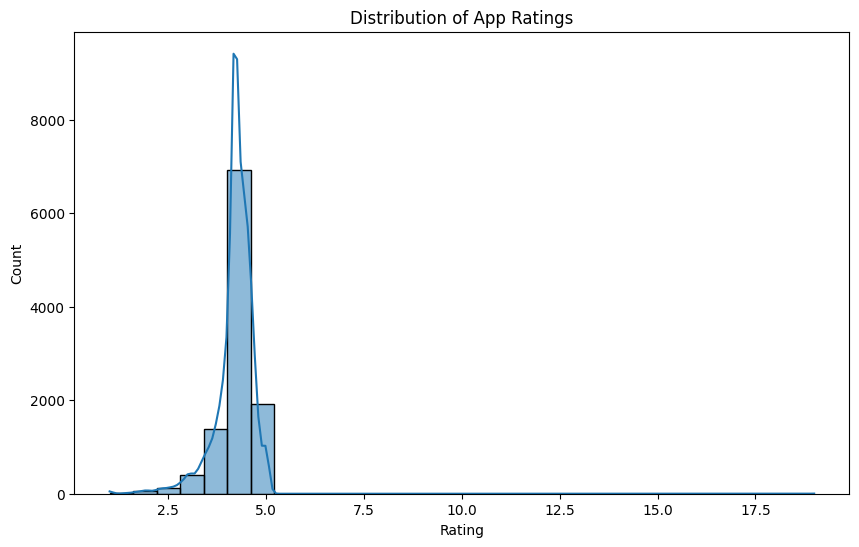

In [19]:
plt.figure(figsize=(10,6))
sns.histplot(df['Rating'], bins=30, kde=True)   
plt.title('Distribution of App Ratings')

plt.show()

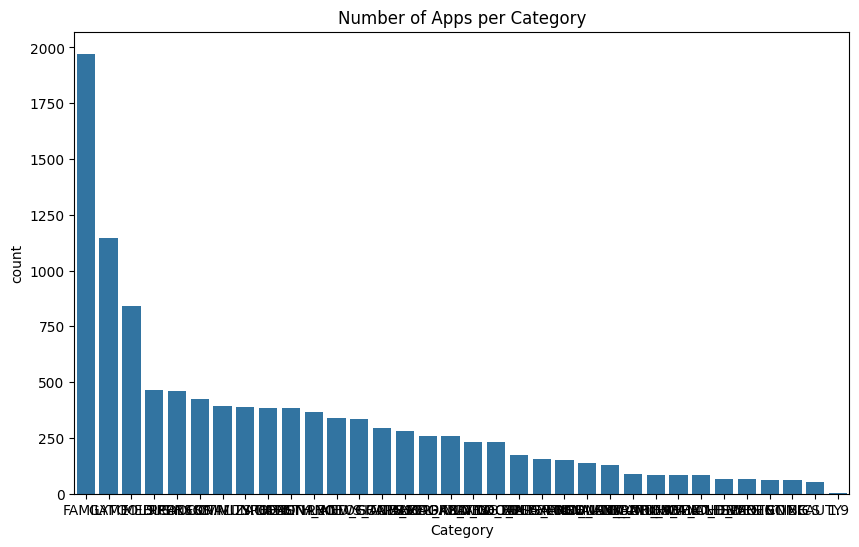

In [20]:
plt.figure(figsize=(10,6))
sns.countplot(x='Category', data=df, order=df['Category'].value_counts().index)
plt.title('Number of Apps per Category')
plt.show()

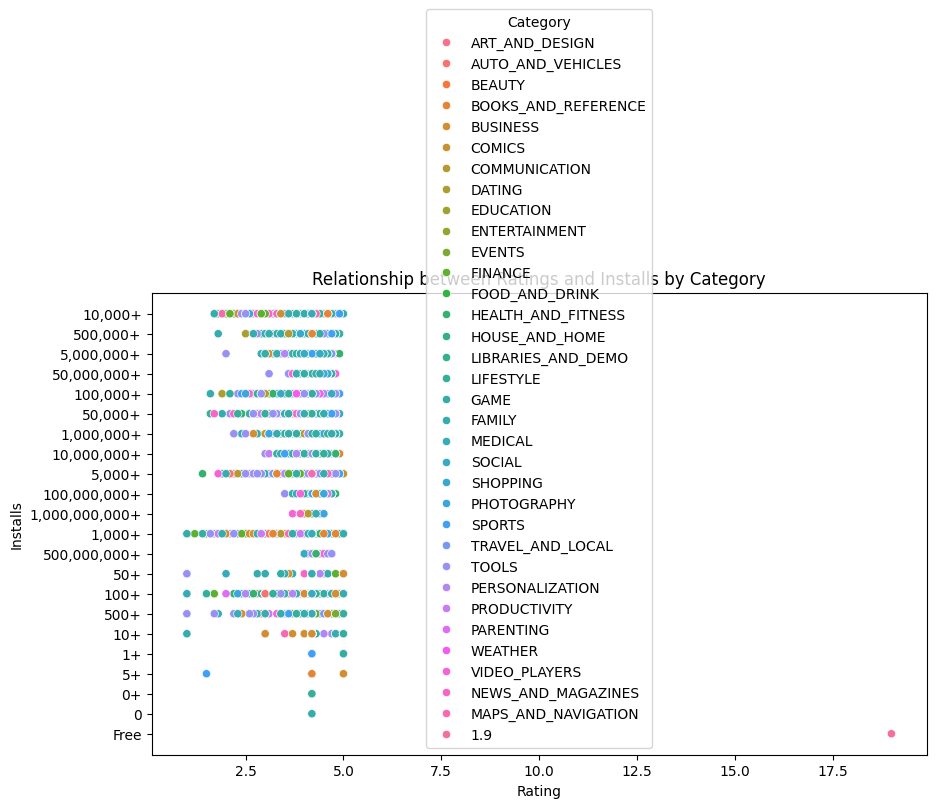

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Rating',y='Installs', hue='Category', data=df)
plt.title('Relationship between Ratings and Installs by Category')
plt.show()

In [24]:
avg_rating_by_category = df.groupby('Category')['Rating'].mean().sort_values(ascending=False)
print(avg_rating_by_category)

Category
1.9                    19.000000
EDUCATION               4.387778
EVENTS                  4.363647
ART_AND_DESIGN          4.350462
BOOKS_AND_REFERENCE     4.311026
PERSONALIZATION         4.307603
GAME                    4.282506
PARENTING               4.282223
HEALTH_AND_FITNESS      4.266296
BEAUTY                  4.260882
SHOPPING                4.254052
SOCIAL                  4.248001
WEATHER                 4.239675
SPORTS                  4.218404
PRODUCTIVITY            4.208287
HOUSE_AND_HOME          4.196819
FAMILY                  4.192394
PHOTOGRAPHY             4.192179
AUTO_AND_VEHICLES       4.190824
MEDICAL                 4.190167
LIBRARIES_AND_DEMO      4.181962
FOOD_AND_DRINK          4.170709
COMMUNICATION           4.163842
COMICS                  4.156445
BUSINESS                4.145987
NEWS_AND_MAGAZINES      4.142993
FINANCE                 4.139108
ENTERTAINMENT           4.126174
TRAVEL_AND_LOCAL        4.119716
LIFESTYLE               4.112427
V

In [25]:
most_installed_apps = df.groupby('Category')['Installs'].sum().sort_values(ascending=False)
print(most_installed_apps)

Category
1.9                                                                 Free
PRODUCTIVITY           500,000,000+10,000,000+100,000,000+10,000,000+...
BEAUTY                 500,000+1,000,000+100,000+500,000+1,000,000+50...
FAMILY                 50,000,000+10,000,000+100,000,000+1,000,000+5,...
WEATHER                50,000,000+1,000,000+50,000,000+10,000+10,000,...
PERSONALIZATION        50,000,000+1,000,000+100,000,000+5,000,000+100...
LIBRARIES_AND_DEMO     50,000+10,000+100,000+1,000+100,000+10,000+100...
LIFESTYLE              5,000,000+10,000,000+100,000+10,000,000+5,000,...
BOOKS_AND_REFERENCE    100,000,000+50,000+100,000+10,000,000+100,000,...
MAPS_AND_NAVIGATION    100,000,000+5,000,000+10,000,000+10,000,000+5,...
EDUCATION              100,000,000+10,000,000+100,000+5,000,000+10,00...
GAME                   100,000,000+1,000,000,000+500,000,000+10,000,0...
ENTERTAINMENT          100,000,000+1,000,000+1,000,000+10,000,000+50,...
EVENTS                 100,000+5,000,000+5

In [26]:
top_genres = df['Genres'].value_counts().head(5)
print(top_genres)

Genres
Tools            842
Entertainment    623
Education        549
Medical          463
Business         460
Name: count, dtype: int64
